## 1. Persiapan dan Import Data

Langkah awal untuk import library yang dibutuhkan dan load dataset penjualan harian kelima
gerai donat, yang berisi harga jual, jumlah unit terjual, pendapatan kotor, biaya variabel,
fixed cost harian, dan balance selama 90 hari per gerai.

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# load dataset dari file csv
df = pd.read_csv('sintesis_data_donat_harian.csv')
# ubah kolom tanggal ke tipe datetime 
df['Tanggal'] = pd.to_datetime(df['Tanggal'])

print(df.info())
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 450 entries, 0 to 449
Data columns (total 8 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   Tanggal                 450 non-null    datetime64[us]
 1   Gerai                   450 non-null    str           
 2   Harga Jual (Rp)         450 non-null    int64         
 3   Jumlah Terjual (Unit)   450 non-null    int64         
 4   Pendapatan Kotor (Rp)   450 non-null    int64         
 5   Biaya Variabel (Rp)     450 non-null    int64         
 6   Fixed Cost Harian (Rp)  450 non-null    int64         
 7   Balance (Rp)            450 non-null    int64         
dtypes: datetime64[us](1), int64(6), str(1)
memory usage: 28.3 KB
None


,Tanggal,Gerai,Harga Jual (Rp),Jumlah Terjual (Unit),Pendapatan Kotor (Rp),Biaya Variabel (Rp),Fixed Cost Harian (Rp),Balance (Rp)
0,2026-01-01,Gerai A,25000,87,2175000,739500,1683333,-247833
1,2026-01-02,Gerai A,25000,81,2025000,688500,1683333,-346833
2,2026-01-03,Gerai A,25000,110,2750000,935000,1683333,131667
3,2026-01-04,Gerai A,25000,119,2975000,1011500,1683333,280167
4,2026-01-05,Gerai A,25000,94,2350000,799000,1683333,-132333


Dataset terdiri dari 450 baris (5 gerai x 90 hari) dan 8 kolom, tidak ada data yang kosong
sehingga bisa langsung dipakai tanpa perlu cleaning tambahan. Kolom yang tersedia sudah
cukup lengkap untuk kebutuhan analisis, yaitu jumlah unit terjual, pendapatan kotor, biaya
variabel, fixed cost, dan balance harian tiap gerai.

## 2. Eksplorasi Data

Melihat statistik dasar dan sebaran data tiap gerai untuk mengecek pola volume penjualan
dan pendapatan.

In [30]:
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)

ringkasan = df.groupby('Gerai').agg(
    rata_rata_unit=('Jumlah Terjual (Unit)', 'mean'),
    std_unit=('Jumlah Terjual (Unit)', 'std'),
    rata_rata_revenue=('Pendapatan Kotor (Rp)', 'mean'),
    rata_rata_balance=('Balance (Rp)', 'mean'),
    hari_untung=('Balance (Rp)', lambda x: (x > 0).sum()),
    hari_rugi=('Balance (Rp)', lambda x: (x <= 0).sum())
).round(0)

print(ringkasan)

         rata_rata_unit  std_unit  rata_rata_revenue  rata_rata_balance  hari_untung  hari_rugi
Gerai                                                                                          
Gerai A            99.0      12.0          2477500.0           -48183.0           31         59
Gerai B           528.0      69.0          4220000.0          1292267.0           90          0
Gerai C           329.0      77.0          3618267.0           292896.0           62         28
Gerai D           150.0      33.0          2996667.0          -748799.0            4         86
Gerai E           227.0      47.0          3399667.0          1171807.0           90          0


In [31]:
print("Korelasi Jumlah Terjual vs Pendapatan Kotor per gerai:")
for gerai in df['Gerai'].unique():
    data_gerai = df[df['Gerai'] == gerai]
    korelasi = np.corrcoef(data_gerai['Jumlah Terjual (Unit)'], data_gerai['Pendapatan Kotor (Rp)'])[0, 1]
    print(f"{gerai}: r = {korelasi:.4f}")

Korelasi Jumlah Terjual vs Pendapatan Kotor per gerai:
Gerai A: r = 1.0000
Gerai B: r = 1.0000
Gerai C: r = 1.0000
Gerai D: r = 1.0000
Gerai E: r = 1.0000


In [32]:
# cek ulang jumlah hari untung vs rugi tiap gerai
for gerai in df['Gerai'].unique():
    data_gerai = df[df['Gerai'] == gerai]
    jumlah_untung = (data_gerai['Balance (Rp)'] > 0).sum()
    jumlah_rugi = (data_gerai['Balance (Rp)'] <= 0).sum()
    total_hari = len(data_gerai)
    print(f"{gerai}: {jumlah_untung} hari untung, {jumlah_rugi} hari rugi, dari total {total_hari} hari")

Gerai A: 31 hari untung, 59 hari rugi, dari total 90 hari
Gerai B: 90 hari untung, 0 hari rugi, dari total 90 hari
Gerai C: 62 hari untung, 28 hari rugi, dari total 90 hari
Gerai D: 4 hari untung, 86 hari rugi, dari total 90 hari
Gerai E: 90 hari untung, 0 hari rugi, dari total 90 hari


Dari tabel di atas terlihat perbedaan performa yang cukup jauh antar gerai. Gerai B dan
Gerai E selalu balance positif di sepanjang 90 hari (0 hari rugi), sedangkan Gerai D
mengalami rugi hampir di seluruh periode (86 dari 90 hari). Gerai A juga lebih sering rugi
dibanding untung, kemungkinan karena volume penjualannya kecil (rata-rata 99 unit/hari)
meski harga jualnya paling tinggi. Ini jadi indikasi awal bahwa breakeven point tiap gerai
akan sangat bervariasi tergantung struktur biaya dan volume penjualannya masing-masing.

### Visualisasi Volume Penjualan vs Revenue

Visualisasi dibuat terpisah per gerai karena harga jual masing-masing berbeda jauh
(Rp8.000 sampai Rp25.000), sehingga skala revenue antar gerai tidak sebanding jika
digabung dalam satu grafik.

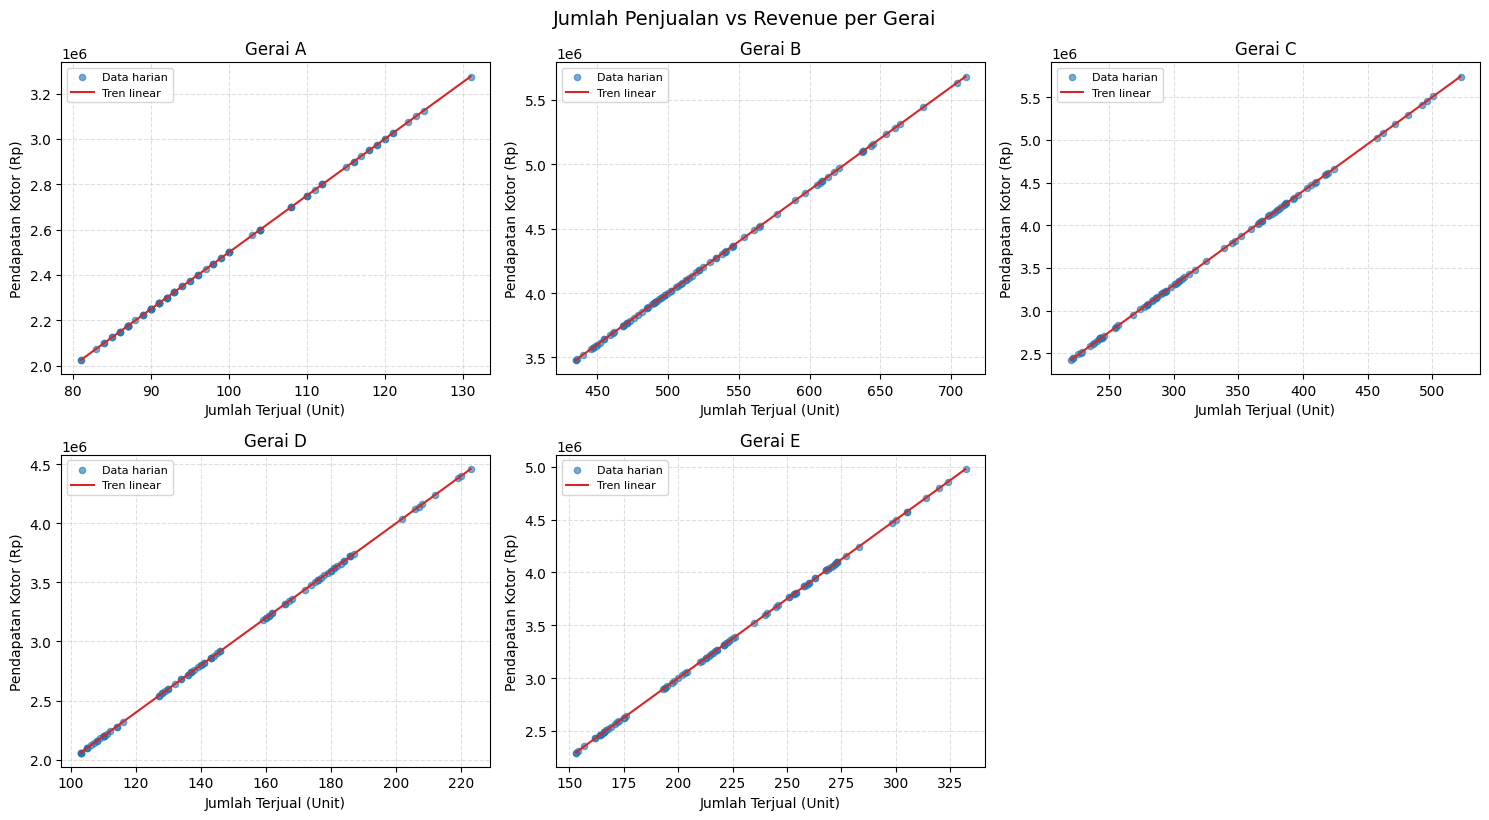

In [33]:
daftar_gerai = df['Gerai'].unique()

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, gerai in enumerate(daftar_gerai):
    data_gerai = df[df['Gerai'] == gerai]
    x = data_gerai['Jumlah Terjual (Unit)'].values
    y = data_gerai['Pendapatan Kotor (Rp)'].values
    
    axes[i].scatter(x, y, alpha=0.6, s=20, color='tab:blue', label='Data harian')
    
    # garis tren linear dari data
    koef = np.polyfit(x, y, 1)
    x_garis = np.linspace(x.min(), x.max(), 100)
    axes[i].plot(x_garis, np.polyval(koef, x_garis), color='tab:red', linewidth=1.5, label='Tren linear')
    
    axes[i].set_title(gerai)
    axes[i].set_xlabel('Jumlah Terjual (Unit)')
    axes[i].set_ylabel('Pendapatan Kotor (Rp)')
    axes[i].legend(fontsize=8)
    axes[i].grid(True, linestyle='--', alpha=0.4)

axes[5].axis('off')
plt.tight_layout()
plt.suptitle('Jumlah Penjualan vs Revenue per Gerai', y=1.02, fontsize=14)
plt.show()

Titik-titik data pada tiap gerai mengikuti garis tren linear dengan sangat rapat, tanpa
penyimpangan. Berarti, ini konsisten dengan nilai korelasi r = 1.0000 yang didapat
sebelumnya, sekaligus memperkuat dugaan bahwa hubungan volume-revenue di data ini memang
murni linear, bukan kebetulan.

## 3. Regresi Revenue terhadap Volume Penjualan

Beberapa model regresi (linear, polinomial derajat 2, dan eksponensial) dicoba untuk
melihat bentuk hubungan revenue dengan volume penjualan tiap gerai, kemudian dibandingkan
menggunakan nilai R² untuk menentukan model mana yang paling sesuai dengan data.

In [34]:
def r_squared(y_aktual, y_prediksi):
    ss_res = np.sum((y_aktual - y_prediksi) ** 2)
    ss_tot = np.sum((y_aktual - np.mean(y_aktual)) ** 2)
    return 1 - (ss_res / ss_tot)

def model_eksponensial(x, a, b):
    return a * np.exp(b * x)

hasil_regresi = {}

for gerai in daftar_gerai:
    data_gerai = df[df['Gerai'] == gerai]
    x = data_gerai['Jumlah Terjual (Unit)'].values
    y = data_gerai['Pendapatan Kotor (Rp)'].values
    
    koef_linear = np.polyfit(x, y, 1)
    y_pred_linear = np.polyval(koef_linear, x)
    r2_linear = r_squared(y, y_pred_linear)
    
    koef_poly2 = np.polyfit(x, y, 2)
    y_pred_poly2 = np.polyval(koef_poly2, x)
    r2_poly2 = r_squared(y, y_pred_poly2)
    
    try:
        param_exp, _ = curve_fit(model_eksponensial, x, y, p0=(1, 0.001), maxfev=5000)
        y_pred_exp = model_eksponensial(x, *param_exp)
        r2_exp = r_squared(y, y_pred_exp)
    except RuntimeError:
        r2_exp = -999
    
    print(f"{gerai}: R2 linear={r2_linear:.4f}, R2 poly2={r2_poly2:.4f}, R2 exp={r2_exp:.4f}")
    
    hasil_regresi[gerai] = {'koef_linear': koef_linear, 'r2_linear': r2_linear}

Gerai A: R2 linear=1.0000, R2 poly2=1.0000, R2 exp=0.9969
Gerai B: R2 linear=1.0000, R2 poly2=1.0000, R2 exp=0.9958
Gerai C: R2 linear=1.0000, R2 poly2=1.0000, R2 exp=0.9859
Gerai D: R2 linear=1.0000, R2 poly2=1.0000, R2 exp=0.9882
Gerai E: R2 linear=1.0000, R2 poly2=1.0000, R2 exp=0.9887


Model linear dan polinomial derajat 2 sama-sama memberikan R² = 1.0000 untuk seluruh
gerai, sedangkan model eksponensial sedikit lebih rendah (R² antara 0.9859 - 0.9969).
Karena model linear dan polinomial derajat 2 memberikan hasil yang identik, model linear
dipilih sebagai model terbaik dengan pertimbangan kesederhanaan (prinsip parsimoni) dan
karena sudah sesuai dengan sifat data bahwa revenue murni hasil kali harga jual konstan
dengan volume penjualan. Model ini yang akan dipakai pada tahap pencarian breakeven point
selanjutnya.

### Regresi Biaya Total terhadap Volume Penjualan

Selain revenue, biaya total (biaya variabel + fixed cost) juga perlu dimodelkan terhadap
volume penjualan, karena breakeven point ditentukan dari titik potong antara fungsi revenue
dan fungsi biaya total.

In [35]:
for gerai in daftar_gerai:
    data_gerai = df[df['Gerai'] == gerai]
    x = data_gerai['Jumlah Terjual (Unit)'].values
    biaya_variabel = data_gerai['Biaya Variabel (Rp)'].values
    fixed_cost = data_gerai['Fixed Cost Harian (Rp)'].values[0]
    
    koef_biaya = np.polyfit(x, biaya_variabel, 1)
    biaya_var_pred = np.polyval(koef_biaya, x)
    r2_biaya = r_squared(biaya_variabel, biaya_var_pred)
    
    print(f"{gerai}: slope biaya variabel = {koef_biaya[0]:.2f}, intercept = {koef_biaya[1]:.2f}, "
          f"R2 = {r2_biaya:.4f}, fixed cost harian = Rp{fixed_cost:,.0f}")
    
    hasil_regresi[gerai]['koef_biaya_variabel'] = koef_biaya
    hasil_regresi[gerai]['fixed_cost'] = fixed_cost

Gerai A: slope biaya variabel = 8500.00, intercept = -0.00, R2 = 1.0000, fixed cost harian = Rp1,683,333
Gerai B: slope biaya variabel = 4160.00, intercept = -0.00, R2 = 1.0000, fixed cost harian = Rp733,333
Gerai C: slope biaya variabel = 4840.00, intercept = -0.00, R2 = 1.0000, fixed cost harian = Rp1,733,333
Gerai D: slope biaya variabel = 7200.00, intercept = 0.00, R2 = 1.0000, fixed cost harian = Rp2,666,666
Gerai E: slope biaya variabel = 6300.00, intercept = 0.00, R2 = 1.0000, fixed cost harian = Rp800,000


Biaya variabel juga terbukti berbanding lurus secara sempurna dengan volume penjualan
(R² = 1.0000 untuk seluruh gerai), dengan slope yang berbeda-beda tiap gerai
Gerai A paling tinggi (Rp8.500/unit), 

Gerai D (Rp7.200/unit),

Gerai E (Rp6.300/unit),

Gerai C (Rp4.840/unit),

Gerai B paling rendah (Rp4.160/unit). 

Fixed cost harian juga bervariasi, dari yang terendah Gerai E (Rp800.000) sampai yang tertinggi Gerai D
(Rp2.666.666), sesuai karakteristik masing-masing gerai. Gerai D sebagai flagship mall
menanggung sewa lokasi tinggi, sementara Gerai E sebagai cloud kitchen tidak perlu ruang
fisik besar meski dikenakan komisi platform pada biaya variabelnya. Dengan diketahui
fungsi revenue dan fungsi biaya total (fixed cost + biaya variabel) sebagai fungsi linear
dari volume, breakeven point tiap gerai dapat dicari menggunakan metode numerik pencarian
akar pada tahap selanjutnya.

## 4. Pencarian Breakeven Point dengan Metode Numerik

Breakeven point (BEP) adalah volume penjualan yang membuat balance sama dengan nol, yaitu
titik di mana revenue tepat menutupi seluruh biaya (fixed cost ditambah biaya variabel).
Berdasarkan model regresi linear pada bagian sebelumnya, fungsi balance dapat dituliskan
sebagai f(x) = Revenue(x) - Biaya Total(x), dengan x adalah volume penjualan harian.

BEP dicari dengan menentukan akar dari f(x) = 0. Dua metode numerik digunakan dan
dibandingkan pada bagian ini, yaitu metode Bisection dan metode Newton-Raphson, untuk
melihat perbedaan jumlah iterasi dan kecepatan konvergensi antara keduanya.

In [36]:
def balance_function(x, harga, slope_biaya, intercept_biaya, fixed_cost):
    # f(x) = revenue(x) - biaya_total(x), akar dari fungsi ini adalah BEP
    revenue = harga * x
    biaya_total = (slope_biaya * x + intercept_biaya) + fixed_cost
    return revenue - biaya_total

def balance_function_turunan(x, harga, slope_biaya):
    # turunan pertama dari balance_function terhadap x, dipakai buat Newton-Raphson
    # karena revenue dan biaya sama-sama linear, turunannya konstan (harga - slope_biaya)
    return harga - slope_biaya

### Metode Bisection

Metode Bisection bekerja dengan membagi dua interval [a, b] secara berulang, selama f(a)
dan f(b) berbeda tanda (mengandung akar di antaranya). Pada tiap iterasi, titik tengah c
dihitung, lalu f(c) dievaluasi untuk menentukan setengah interval mana yang masih
mengandung akar, dan proses ini diulang sampai interval cukup sempit atau nilai f(c)
mendekati nol. Metode ini selalu konvergen selama syarat awal terpenuhi, meski
kecepatannya relatif lambat dibanding metode lain.

In [37]:
def bisection(f, a, b, toleransi=1e-4, maks_iterasi=100):
    if f(a) * f(b) > 0:
        print("Tidak ada perubahan tanda di rentang ini, batas awal perlu disesuaikan")
        return None, []
    
    riwayat_iterasi = []
    for i in range(maks_iterasi):
        c = (a + b) / 2
        fc = f(c)
        riwayat_iterasi.append({'iterasi': i + 1, 'a': a, 'b': b, 'c': c, 'f(c)': fc})
        
        if abs(fc) < toleransi or (b - a) / 2 < toleransi:
            return c, riwayat_iterasi
        
        if f(a) * fc < 0:
            b = c
        else:
            a = c
    
    return c, riwayat_iterasi

### Metode Newton-Raphson

Metode Newton-Raphson mencari akar dengan memanfaatkan turunan fungsi, menggunakan formula
iteratif x_baru = x_lama - f(x_lama) / f'(x_lama). Metode ini pada umumnya konvergen jauh
lebih cepat dibanding Bisection karena setiap iterasi langsung mengarah ke akar berdasarkan
kemiringan garis singgung fungsi di titik tersebut, meski membutuhkan turunan fungsi yang
bisa dihitung dan tebakan awal yang cukup dekat dengan akar sebenarnya.

In [38]:
def newton_raphson(f, f_turunan, x0, toleransi=1e-4, maks_iterasi=100):
    riwayat_iterasi = []
    x = x0
    
    for i in range(maks_iterasi):
        fx = f(x)
        fpx = f_turunan(x)
        
        riwayat_iterasi.append({'iterasi': i + 1, 'x': x, 'f(x)': fx})
        
        if abs(fx) < toleransi:
            return x, riwayat_iterasi
        
        x_baru = x - fx / fpx
        x = x_baru
    
    return x, riwayat_iterasi

### Penerapan Kedua Metode untuk Kelima Gerai

Kedua metode diterapkan pada tiap gerai menggunakan koefisien hasil regresi sebelumnya.
Untuk Bisection, interval awal [0, 2000] dipakai karena mencakup rentang volume penjualan
yang realistis untuk kelima gerai. Untuk Newton-Raphson, tebakan awal x0 = 100 dipakai
sebagai titik mulai.

In [39]:
hasil_bep = {}

for gerai in daftar_gerai:
    harga = df[df['Gerai'] == gerai]['Harga Jual (Rp)'].values[0]
    slope_biaya, intercept_biaya = hasil_regresi[gerai]['koef_biaya_variabel']
    fixed_cost = hasil_regresi[gerai]['fixed_cost']
    
    f = lambda x: balance_function(x, harga, slope_biaya, intercept_biaya, fixed_cost)
    fp = lambda x: balance_function_turunan(x, harga, slope_biaya)
    
    bep_bisection, riwayat_bisection = bisection(f, a=0, b=2000)
    bep_newton, riwayat_newton = newton_raphson(f, fp, x0=100)
    
    hasil_bep[gerai] = {
        'bep_bisection': bep_bisection,
        'iterasi_bisection': len(riwayat_bisection),
        'bep_newton': bep_newton,
        'iterasi_newton': len(riwayat_newton),
        'riwayat_bisection': riwayat_bisection,
        'riwayat_newton': riwayat_newton
    }
    
    print(f"{gerai}: BEP Bisection = {bep_bisection:.2f} unit ({len(riwayat_bisection)} iterasi), "
          f"BEP Newton-Raphson = {bep_newton:.2f} unit ({len(riwayat_newton)} iterasi)")

Gerai A: BEP Bisection = 102.02 unit (25 iterasi), BEP Newton-Raphson = 102.02 unit (2 iterasi)
Gerai B: BEP Bisection = 190.97 unit (25 iterasi), BEP Newton-Raphson = 190.97 unit (2 iterasi)
Gerai C: BEP Bisection = 281.39 unit (25 iterasi), BEP Newton-Raphson = 281.39 unit (2 iterasi)
Gerai D: BEP Bisection = 208.33 unit (25 iterasi), BEP Newton-Raphson = 208.33 unit (2 iterasi)
Gerai E: BEP Bisection = 91.95 unit (25 iterasi), BEP Newton-Raphson = 91.95 unit (2 iterasi)


Kedua metode menghasilkan nilai BEP yang identik untuk seluruh gerai, yang mengonfirmasi
bahwa hasil pencarian akar sudah benar dan tidak bergantung pada metode yang dipakai.
Perbedaan paling mencolok terlihat pada jumlah iterasi: Bisection membutuhkan 25 iterasi
untuk tiap gerai, sedangkan Newton-Raphson hanya butuh 2 iterasi. Hal ini sesuai dengan
teori bahwa Newton-Raphson memiliki konvergensi kuadratik sedangkan Bisection hanya
konvergensi linear, sehingga Newton-Raphson jauh lebih efisien terutama karena fungsi
balance pada kasus ini berbentuk linear sehingga turunannya konstan dan mudah dihitung.

Nilai BEP kelima gerai adalah sebagai berikut: 
Gerai A = 102,02 unit/hari, 

Gerai B = 190,97 unit/hari, 

Gerai C = 281,39 unit/hari, 

Gerai D = 208,33 unit/hari,
  
Gerai E = 91,95 unit/hari.

### Contoh Detail Proses Iterasi

Sebagai ilustrasi proses konvergensi, berikut ditampilkan tabel iterasi lengkap untuk
Gerai A menggunakan kedua metode.

In [40]:
print("Iterasi Bisection - Gerai A")
df_bisection_a = pd.DataFrame(hasil_bep['Gerai A']['riwayat_bisection'])
print(df_bisection_a.to_string(index=False))

print("\nIterasi Newton-Raphson - Gerai A")
df_newton_a = pd.DataFrame(hasil_bep['Gerai A']['riwayat_newton'])
print(df_newton_a.to_string(index=False))

Iterasi Bisection - Gerai A
 iterasi          a           b           c          f(c)
       1   0.000000 2000.000000 1000.000000  1.481667e+07
       2   0.000000 1000.000000  500.000000  6.566667e+06
       3   0.000000  500.000000  250.000000  2.441667e+06
       4   0.000000  250.000000  125.000000  3.791670e+05
       5   0.000000  125.000000   62.500000 -6.520830e+05
       6  62.500000  125.000000   93.750000 -1.364580e+05
       7  93.750000  125.000000  109.375000  1.213545e+05
       8  93.750000  109.375000  101.562500 -7.551750e+03
       9 101.562500  109.375000  105.468750  5.690138e+04
      10 101.562500  105.468750  103.515625  2.467481e+04
      11 101.562500  103.515625  102.539062  8.561531e+03
      12 101.562500  102.539062  102.050781  5.048906e+02
      13 101.562500  102.050781  101.806641 -3.523430e+03
      14 101.806641  102.050781  101.928711 -1.509270e+03
      15 101.928711  102.050781  101.989746 -5.021895e+02
      16 101.989746  102.050781  102.020264 

Tabel iterasi Bisection menunjukkan interval [a, b] yang terus menyempit secara bertahap
sampai nilai tengah c konvergen ke titik akar, sedangkan tabel Newton-Raphson menunjukkan
nilai x yang langsung melompat mendekati akar hanya dalam dua langkah karena memanfaatkan
informasi turunan fungsi secara langsung.

### Perbandingan BEP dengan Rata-Rata Penjualan Aktual

Setelah BEP tiap gerai diketahui, langkah terakhir adalah membandingkannya dengan rata-rata
volume penjualan aktual masing-masing gerai untuk melihat gerai mana yang secara umum
beroperasi di atas atau di bawah titik impasnya.

In [41]:
tabel_bep = []

for gerai in daftar_gerai:
    rata_rata_aktual = df[df['Gerai'] == gerai]['Jumlah Terjual (Unit)'].mean()
    bep = hasil_bep[gerai]['bep_newton']
    selisih_persen = ((rata_rata_aktual - bep) / bep) * 100
    
    tabel_bep.append({
        'Gerai': gerai,
        'BEP (unit/hari)': round(bep, 2),
        'Rata-rata Penjualan (unit/hari)': round(rata_rata_aktual, 2),
        'Selisih (%)': round(selisih_persen, 2),
        'Status': 'Di atas BEP' if rata_rata_aktual > bep else 'Di bawah BEP'
    })

df_bep = pd.DataFrame(tabel_bep)
print(df_bep.to_string(index=False))

  Gerai  BEP (unit/hari)  Rata-rata Penjualan (unit/hari)  Selisih (%)       Status
Gerai A           102.02                            99.10        -2.86 Di bawah BEP
Gerai B           190.97                           527.50       176.22  Di atas BEP
Gerai C           281.39                           328.93        16.90  Di atas BEP
Gerai D           208.33                           149.83       -28.08 Di bawah BEP
Gerai E            91.95                           226.64       146.48  Di atas BEP


Hasil perbandingan menunjukkan bahwa Gerai B dan Gerai E memiliki margin keamanan paling
besar terhadap BEP, dengan rata-rata penjualan masing-masing 176,22% dan 146,48% di atas
titik impas. Gerai C juga beroperasi di atas BEP meski dengan margin lebih tipis (16,90%).
Sebaliknya, Gerai A dan Gerai D secara rata-rata beroperasi di bawah BEP, masing-masing
-2,86% dan -28,08%, yang menjelaskan mengapa kedua gerai ini mendominasi hari-hari rugi
pada eksplorasi data di awal (Gerai A rugi 59 dari 90 hari, Gerai D rugi 86 dari 90 hari).


Gerai D berada dalam kondisi paling mengkhawatirkan dengan selisih -28,08% dari BEP,
sejalan dengan fixed cost hariannya yang paling tinggi di antara kelima gerai
(Rp2.666.666) akibat sewa lokasi flagship mall yang mahal, sementara volume penjualannya
tidak cukup besar untuk menutupinya. Gerai A juga berada tepat di ambang BEP (-2,86%),
menunjukkan bahwa strategi premium dengan harga tinggi namun volume terbatas membuat
gerai ini rentan berayun antara

## 5. Visualisasi Ringkasan BEP

Sebagai penutup, breakeven point dan rata-rata penjualan aktual kelima gerai ditampilkan
dalam satu grafik batang untuk memudahkan perbandingan visual secara langsung.

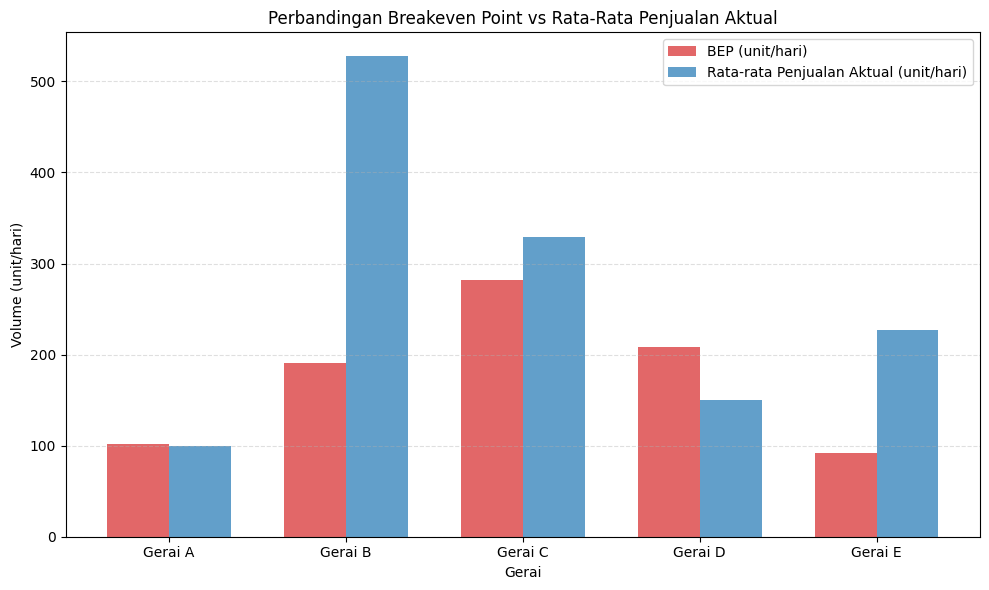

In [42]:
fig, ax = plt.subplots(figsize=(10, 6))

x_pos = np.arange(len(daftar_gerai))
lebar_bar = 0.35

bep_values = [hasil_bep[gerai]['bep_newton'] for gerai in daftar_gerai]
rata_values = [df[df['Gerai'] == gerai]['Jumlah Terjual (Unit)'].mean() for gerai in daftar_gerai]

ax.bar(x_pos - lebar_bar/2, bep_values, lebar_bar, label='BEP (unit/hari)', color='tab:red', alpha=0.7)
ax.bar(x_pos + lebar_bar/2, rata_values, lebar_bar, label='Rata-rata Penjualan Aktual (unit/hari)', color='tab:blue', alpha=0.7)

ax.set_xlabel('Gerai')
ax.set_ylabel('Volume (unit/hari)')
ax.set_title('Perbandingan Breakeven Point vs Rata-Rata Penjualan Aktual')
ax.set_xticks(x_pos)
ax.set_xticklabels(daftar_gerai)
ax.legend()
ax.grid(True, axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

Grafik di atas memperjelas temuan sebelumnya: batang biru (rata-rata penjualan) yang
melampaui batang merah (BEP) pada Gerai B, C, dan E menunjukkan rata-rata penjualan
ketiga gerai ini telah melampaui titik impas. Perlu dicatat bahwa ini adalah gambaran
rata-rata, bukan berarti gerai tersebut untung setiap harinya secara konsisten.Gerai C
misalnya tetap mencatat rugi pada 28 dari 90 hari observasi (lihat tabel eksplorasi data
di awal), meski secara rata-rata penjualannya sudah di atas BEP. Sebaliknya, pada Gerai A
dan Gerai D batang birunya berada di bawah atau setara batang merah, mengindikasikan
rata-rata operasional yang belum mencapai titik impas.